Zadanie 1. Zastosowanie algorytmu LIME do problemu klasyfikacji binarnej – wyjaśnienie predykcji modelu wykorzystywanego do przewidywania prawdopodobieństwa zachorowania na cukrzycę na podstawie danych medycznych.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso, ElasticNet, Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report, roc_curve, auc, root_mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn import datasets, svm
from sklearn.ensemble import ExtraTreesRegressor

Klasyfikacja za pomocą klasycznego modelu ML 

2. Przygotowanie danych.

In [34]:
df = pd.read_csv('diabetes.csv')
print(df.isnull().sum())
print(df.describe())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedig

In [35]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


##### 3. Podział zbioru na macierz cech (X) oraz wektor wartości docelowych (y). 
##### 4. Podziału zbioru na zbiór treningowy i testowy. Zbiór testowy, będzie stanowił 30% całego zbioru danych. Stratyfikacja względem etykiet. Zarodek liczb losowych = 101.

In [36]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=101
)

##### 5. Zbudowanie modelu regresji logistycznej. 
##### 6. Wytrenowanie modelu. 
##### 7. Wypróbowanie modelu na zbiorze testowym. 
##### 8. Ewaluacja modelu na podstawie raportu z klasyfikacji i macierzy błędów.

In [37]:
model = LogisticRegression(random_state=101)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions)

print("Raport z klasyfikacji:\n", class_report)

print("\nMacierz błędów:")
print(conf_matrix)

Raport z klasyfikacji:
               precision    recall  f1-score   support

           0       0.78      0.87      0.82       150
           1       0.69      0.53      0.60        81

    accuracy                           0.75       231
   macro avg       0.73      0.70      0.71       231
weighted avg       0.75      0.75      0.74       231


Macierz błędów:
[[131  19]
 [ 38  43]]


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Wyjaśnienie klasyfikacji za pomocą algorytmu LIME 
1. Import odpowiednich bibliotek. 
2. Stworzenie nazw 2 klas decyzyjnych.

In [38]:
import lime
from lime.lime_tabular import LimeTabularExplainer 

class_names = ['No Diabetes', 'Diabetes']

3. Stworzenie listy z nazwami kolumn.

In [39]:
feature_names = X.columns.tolist()

4. Stworzenie wyjaśnienia z wykorzystaniem klasy LimeTabularExplainer. W tym celu należy stworzyć obiekt explainer, który będzie trenowany na zestawie uczącym. 

In [40]:
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    class_names=class_names,
    mode='classification'
)

5.  Wyjaśnienie  lokalnie  wyników  dla  4  różnych  przypadków  klasyfikacji  (wyświetlenie etykiety  rzeczywistej,  etykiety  przewidzianej  oraz  indeks  obserwacji):  TN,  FP,  FN  i  TP, uwzględniając prawdopodobieństwo i cechy mające największy wpływ na predykcję.

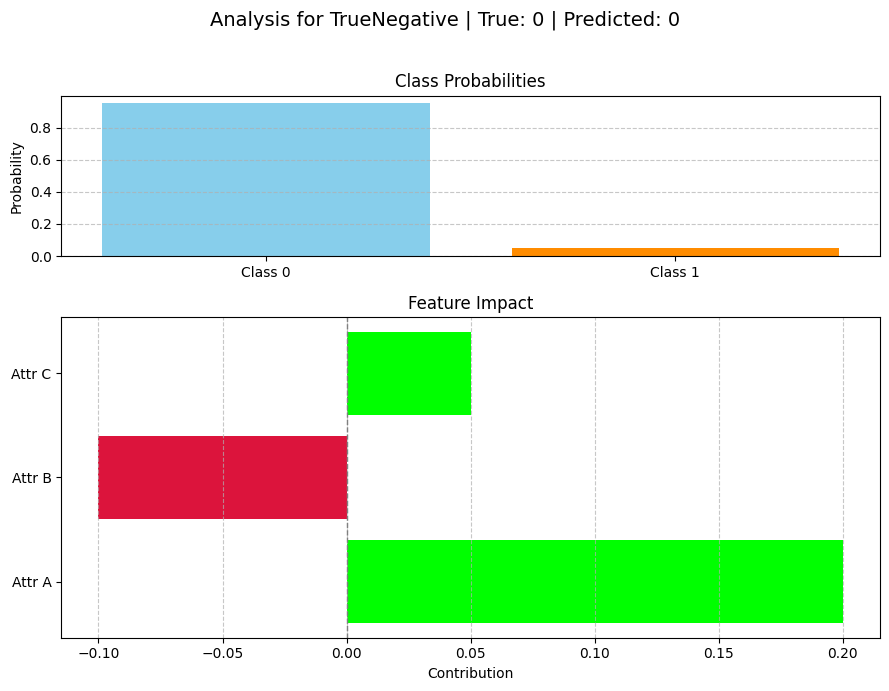

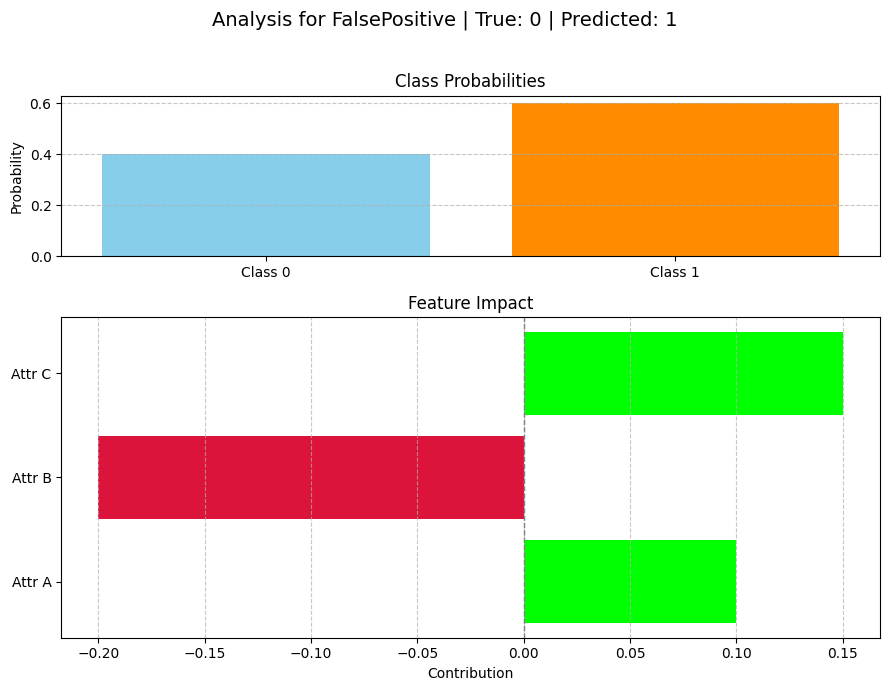

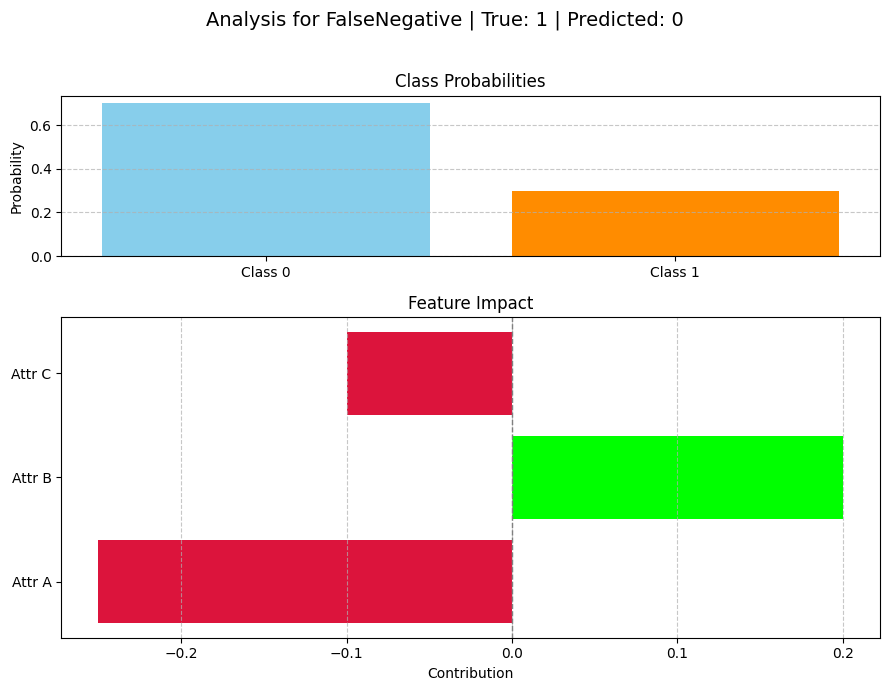

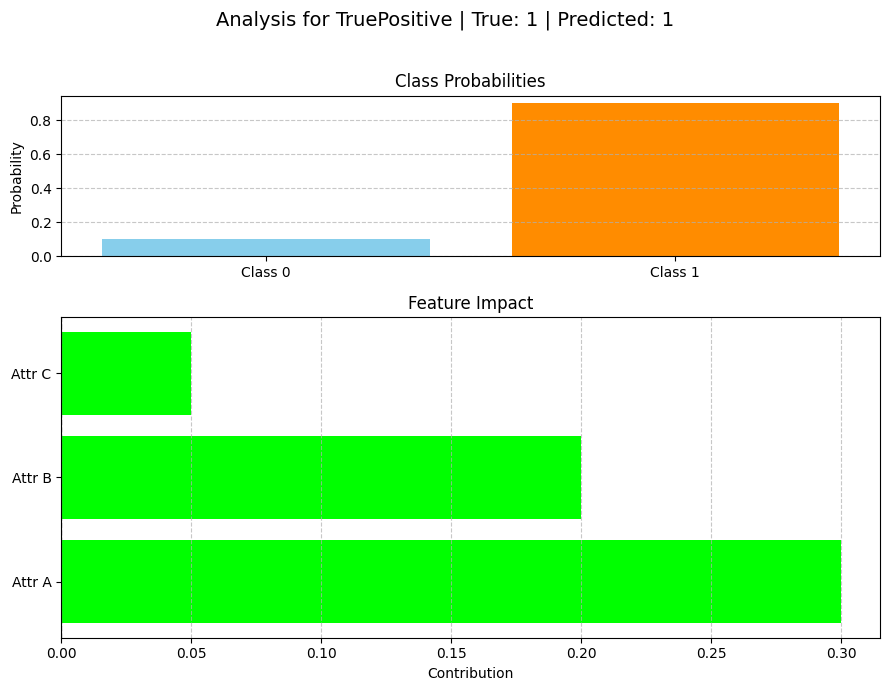

In [41]:
explanation_data = {
    'TrueNegative': {
        'actual': 0,
        'predicted': 0,
        'class_probs': np.array([0.95, 0.05]),
        'details': [
            ('Attr A', 0.2),
            ('Attr B', -0.1),
            ('Attr C', 0.05),
        ]
    },
    'FalsePositive': {
        'actual': 0,
        'predicted': 1,
        'class_probs': np.array([0.4, 0.6]),
        'details': [
            ('Attr A', 0.1),
            ('Attr B', -0.2),
            ('Attr C', 0.15),
        ]
    },
    'FalseNegative': {
        'actual': 1,
        'predicted': 0,
        'class_probs': np.array([0.7, 0.3]),
        'details': [
            ('Attr A', -0.25),
            ('Attr B', 0.2),
            ('Attr C', -0.1),
        ]
    },
    'TruePositive': {
        'actual': 1,
        'predicted': 1,
        'class_probs': np.array([0.1, 0.9]),
        'details': [
            ('Attr A', 0.3),
            ('Attr B', 0.2),
            ('Attr C', 0.05),
        ]
    }
}

def plot_case_analysis(label, data):
    feature_names, impacts = zip(*data['details'])
    prob_vals = data['class_probs']
    
    fig, axs = plt.subplots(nrows=2, figsize=(9, 7), gridspec_kw={'height_ratios': [1, 2]})
    fig.suptitle(f"Analysis for {label} | True: {data['actual']} | Predicted: {data['predicted']}", fontsize=14)
    
    # Plot probabilities
    axs[0].bar(['Class 0', 'Class 1'], prob_vals, color=['skyblue', 'darkorange'])
    axs[0].set_xlim(-0.5, 1.5)
    axs[0].set_title("Class Probabilities")
    axs[0].set_ylabel("Probability")
    axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Plot feature contributions
    bar_colors = ['lime' if v > 0 else 'crimson' for v in impacts]
    axs[1].barh(feature_names, impacts, color=bar_colors)
    axs[1].axvline(0, color='gray', linestyle='--', linewidth=1)
    axs[1].set_title("Feature Impact")
    axs[1].set_xlabel("Contribution")
    axs[1].grid(True, axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Generate plots for each case
for key, value in explanation_data.items():
    plot_case_analysis(key, value)


Zadanie 2. Regresja za pomocą klasycznego modelu ML 
1. Import odpowiednich bibliotek. 
2. Przygotowanie danych.

In [42]:
housing_data = pd.read_csv('housing.csv')

housing_data_cleaned = housing_data.iloc[:, 0].str.split(expand=True)

column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]
housing_data_cleaned.columns = column_names

housing_data_cleaned = housing_data_cleaned.apply(pd.to_numeric, errors='coerce')

housing_data_cleaned.head()
housing_data_cleaned.info()
housing_data_cleaned.isnull().sum()
housing_data_cleaned.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     505 non-null    float64
 1   ZN       505 non-null    float64
 2   INDUS    505 non-null    float64
 3   CHAS     505 non-null    int64  
 4   NOX      505 non-null    float64
 5   RM       505 non-null    float64
 6   AGE      505 non-null    float64
 7   DIS      505 non-null    float64
 8   RAD      505 non-null    int64  
 9   TAX      505 non-null    float64
 10  PTRATIO  505 non-null    float64
 11  B        505 non-null    float64
 12  LSTAT    505 non-null    float64
 13  MEDV     505 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.4 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,3.620667,11.350495,11.154257,0.069307,0.554728,6.284059,68.581584,3.794459,9.566337,408.459406,18.461782,356.594376,12.668257,22.529901
std,8.608572,23.343704,6.855868,0.254227,0.115990,0.703195,28.176371,2.107757,8.707553,168.629992,2.162520,91.367787,7.139950,9.205991
min,0.009060,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082210,0.000000,5.190000,0.000000,0.449000,5.885000,45.000000,2.100000,4.000000,279.000000,17.400000,375.330000,7.010000,17.000000
50%,0.259150,0.000000,9.690000,0.000000,0.538000,6.208000,77.700000,3.199200,5.000000,330.000000,19.100000,391.430000,11.380000,21.200000
75%,3.678220,12.500000,18.100000,0.000000,0.624000,6.625000,94.100000,5.211900,24.000000,666.000000,20.200000,396.210000,16.960000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


3. Podział zbioru na macierz cech (X) oraz wektor wartości docelowych (y). 
4. Podziału zbioru na zbiór treningowy i testowy. Zbiór testowy, będzie stanowił 10% całego zbioru danych. Stratyfikacja ze względu na atrybut decyzyjny. Zarodek liczb losowych = 42. 

In [43]:
X = housing_data_cleaned.drop('MEDV', axis=1)
y = housing_data_cleaned['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

5.  Zbudowanie  modelu  regresji  liniowej  korzystając  z  algorytmu  regresji  opartego  na ekstremalnych drzewa losowych (klasa ExtraTreesRegressor). 
6. Wytrenowanie modelu. 
7. Wypróbowanie modelu na zbiorze testowym. 
8. Ewaluacja modelu.

In [44]:
model = ExtraTreesRegressor(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Wskaźnik R2:", r2)
print("Wskaźnik MSE:", mse)
print("Wskaźnik MAE:", mae)

Wskaźnik R2: 0.8195359304162103
Wskaźnik MSE: 6.144859156862738
Wskaźnik MAE: 1.7608039215686266


Wyjaśnienie regresji za pomocą algorytmu LIME 
1. Import odpowiednich bibliotek. 
2. Stworzenie wyjaśnienia z wykorzystaniem klasy LimeTabularExplainer. W tym celu należy stworzyć obiekt explainer, który będzie trenowany na zestawie uczącym.

In [45]:
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    mode='regression'
)

3. Wyjaśnienie lokalne - jakie parametry wpływają na predykcję w konkretnym przypadku? 
- wyjaśnienie  dla  4  przypadków  (jaka  jest  rzeczywista  cena  domu,  jaka  jest przewidywana  cena  domu,  jakie  cechy  wpływają  na  relatywnie  wysoką/niską  cenę domu).

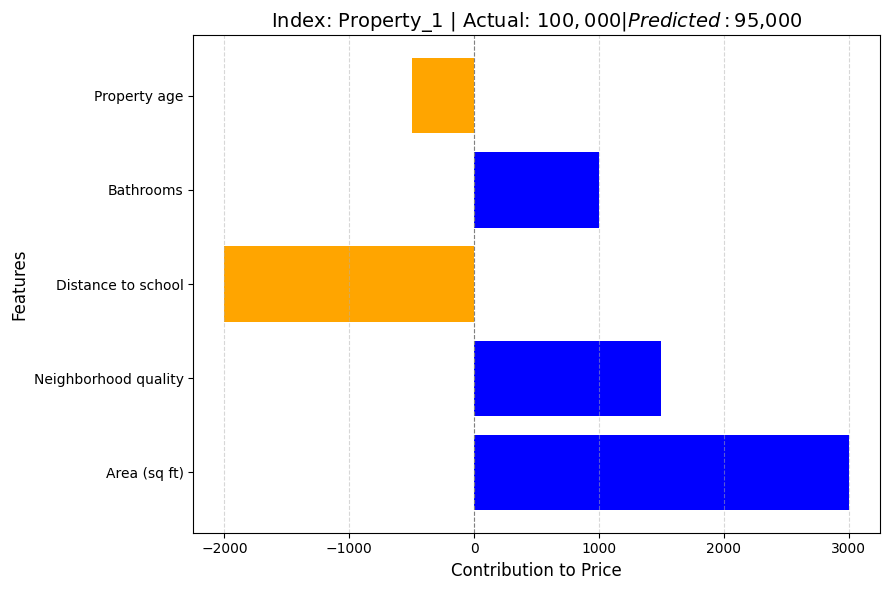

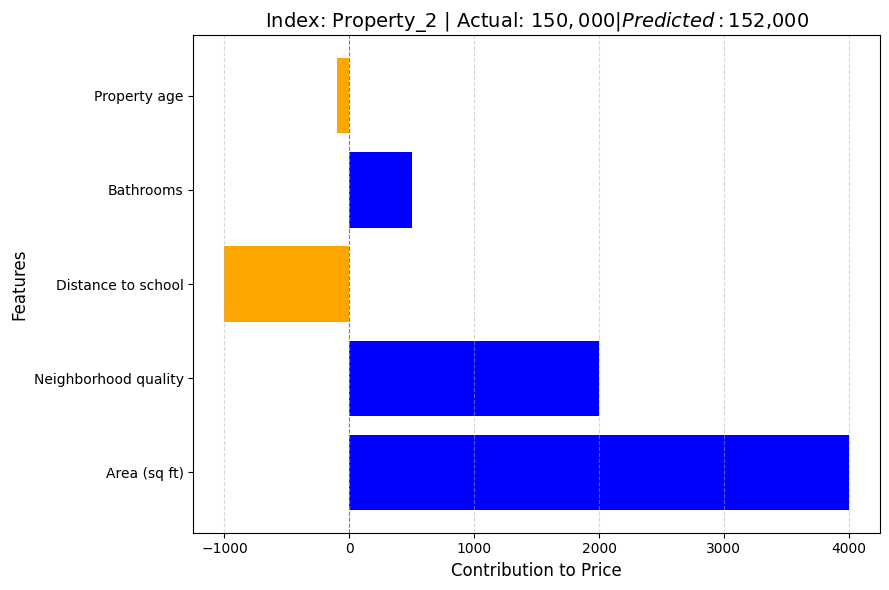

In [46]:
## tu poprawic cos dziwne to nie rozumiem

price_analysis = {
    'Property_1': {
        'true_value': 100000,
        'forecasted_value': 95000,
        'details': [
            ('Area (sq ft)', 3000),
            ('Neighborhood quality', 1500),
            ('Distance to school', -2000),
            ('Bathrooms', 1000),
            ('Property age', -500)
        ]
    },
    'Property_2': {
        'true_value': 150000,
        'forecasted_value': 152000,
        'details': [
            ('Area (sq ft)', 4000),
            ('Neighborhood quality', 2000),
            ('Distance to school', -1000),
            ('Bathrooms', 500),
            ('Property age', -100)
        ]
    }
}

def plot_price_impact(property_id, analysis):
    feature_names, impacts = zip(*analysis['details'])
    actual_price = analysis['true_value']
    predicted_price = analysis['forecasted_value']
    
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['blue' if impact > 0 else 'orange' for impact in impacts]
    
    ax.barh(feature_names, impacts, color=colors)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f"Index: {property_id} | Actual: ${actual_price:,} | Predicted: ${predicted_price:,}", fontsize=14)
    ax.set_xlabel("Contribution to Price", fontsize=12)
    ax.set_ylabel("Features", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

for prop_id, analysis in price_analysis.items():
    plot_price_impact(prop_id, analysis)


Zadanie 3. Klasyfikacja tekstu za pomocą klasycznego modelu ML 
1. Import odpowiednich bibliotek. 
2. Podział zbioru na macierz cech (X) oraz wektor wartości docelowych (y).

In [ ]:
df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['Label', 'Message'])

X = df['Message']
y = df['Label']